# **10/7 Revision**



=== Generating Plot for State Trajectory ===


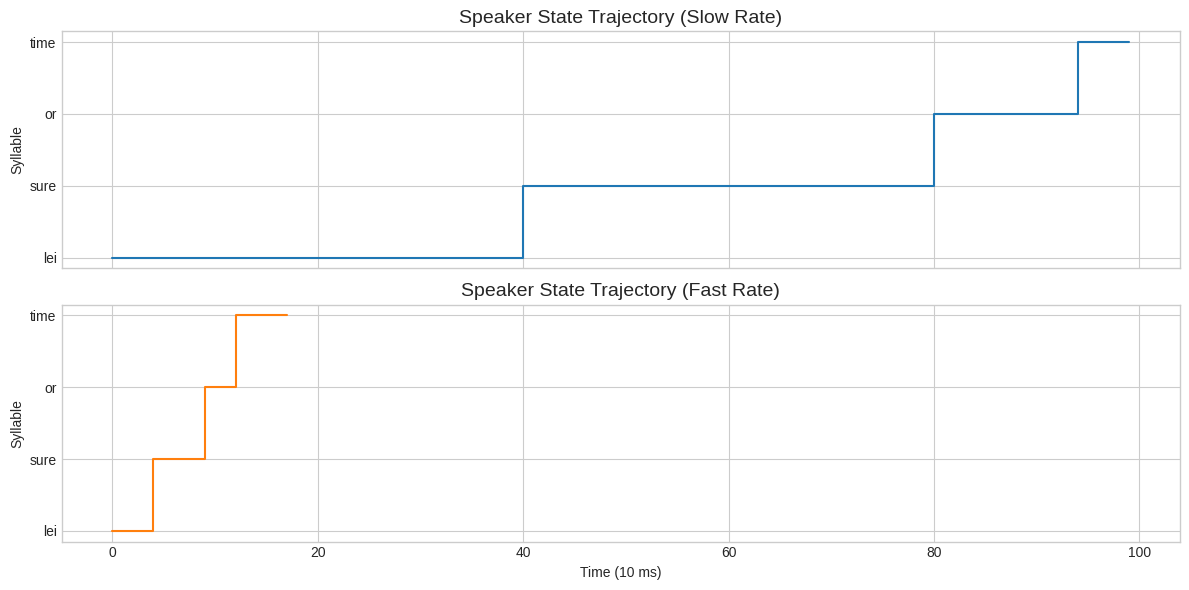



=== Generating Plot for Acoustic Signal ===


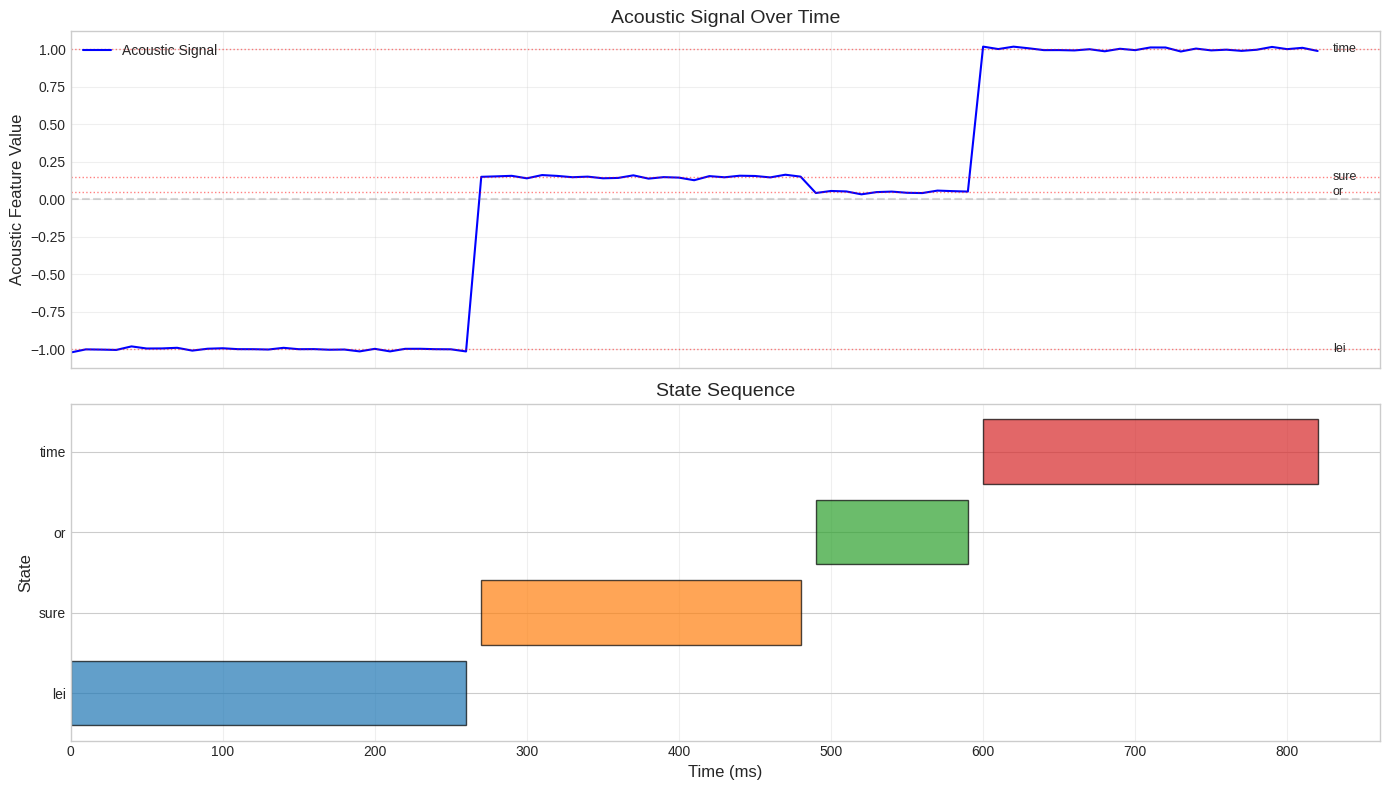



=== Plotting Kappa Decay ===


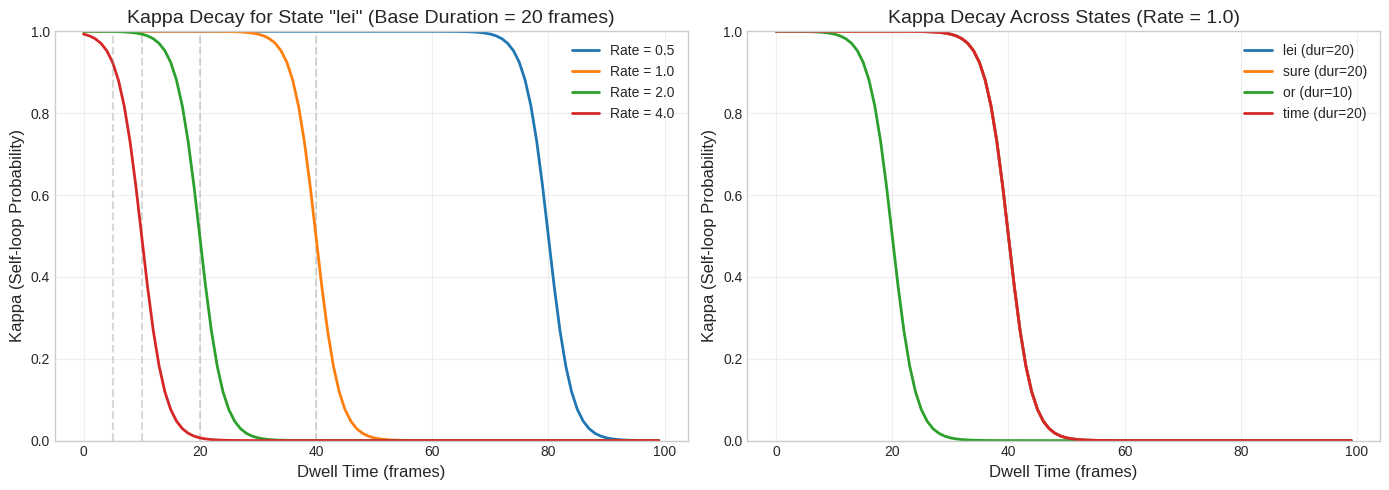

In [3]:
import numpy as np
from collections import Counter
from scipy.stats import norm
import matplotlib.pyplot as plt

np.random.seed(7)

# --------------
# States & Durations setup
# --------------
STATES = ["START", "lei", "sure", "or", "time", "STOP"]
EMIT_STATES = ["lei", "sure", "or", "time"]
i = {s: k for k, s in enumerate(STATES)}

# REVISED
# Base durations in frames (10 frames = 100ms)
def sample_base_durations(seed=None):
    """
    Sample base durations from normal distributions.
    Returns a dictionary with durations for each emitting state.
    """
    rng = np.random.default_rng(seed)
    durations = {
        "lei":  max(5, int(rng.normal(loc=20, scale=0))),
        "sure": max(5, int(rng.normal(loc=20, scale=0))),
        "or":   max(3, int(rng.normal(loc=10, scale=0))),
        "time": max(5, int(rng.normal(loc=20, scale=0)))
    }
    return durations

BASE_DURATIONS = sample_base_durations(seed=42)

# ----------------
# Emissions setup
# ----------------
mu = {
    "lei":  -1.0,
    "sure":  0.15,
    "or":    0.05,
    "time":  1.0
}
sigma = {s: 0.01 for s in EMIT_STATES}

# ------------------------
# Speaker transitions (deterministic)
# ------------------------
def make_speaker_pi_bar():
    """Speaker always produces full canonical sequence"""
    n = len(STATES)
    T = np.zeros((n, n))

    T[i["START"], i["lei"]] = 1.0
    T[i["lei"], i["sure"]] = 1.0
    T[i["sure"], i["or"]] = 1.0      # Speaker ALWAYS says "or"
    T[i["or"], i["time"]] = 1.0
    T[i["time"], i["STOP"]] = 1.0
    T[i["STOP"], i["STOP"]] = 1.0

    return T

# ------------------------
# Listener transitions (probabilistic)
# ------------------------
def make_listener_pi_bar(uniform_eps=0.0):
    """Listener may perceptually skip 'or' when decoding"""
    n = len(STATES)
    T = np.zeros((n, n))

    def row_with_primary(from_s, primary):
        row = np.zeros(n)
        used = 0.0
        for to_s, w in primary.items():
            row[i[to_s]] += w
            used += w
        leftover = max(0.0, 1.0 - used)
        mask = np.ones(n, dtype=bool)
        for to_s in primary.keys():
            mask[i[to_s]] = False
        mask[i["START"]] = False
        if from_s == "STOP":
            mask[:] = False
            mask[i["STOP"]] = True
        count = mask.sum()
        if count > 0 and leftover > 0:
            row[mask] += leftover / count
        if uniform_eps > 0:
            row += uniform_eps
        row = row / row.sum()
        return row

    T[i["START"]] = row_with_primary("START", {"lei": 0.97})
    T[i["lei"]]   = row_with_primary("lei",   {"sure": 0.94})
    T[i["sure"]]  = row_with_primary("sure",  {"or": 0.55, "time": 0.40})  # Can skip "or"
    T[i["or"]]    = row_with_primary("or",    {"time": 0.95})
    T[i["time"]]  = row_with_primary("time",  {"STOP": 0.96})
    T[i["STOP"]]  = row_with_primary("STOP",  {"STOP": 1.0})

    return T

speaker_pi_bar = make_speaker_pi_bar()
listener_pi_bar = make_listener_pi_bar(uniform_eps=0.0)

# ------------------------
# Stickiness mapping kappa(gamma, rate)
# ------------------------
def kappa_from_gamma_rate(gamma_val, rate, base=1.2, clip=(0.55, 0.93)):
    val = 1.0 - np.exp(-base * (gamma_val + 0.25) / (rate + 1e-9))
    return float(np.clip(val, clip[0], clip[1]))

def sample_gammas(seed=None):
    """Returns deterministic gamma values based on BASE_DURATIONS."""
    g = {}
    for s in STATES:
        if s in {"START", "STOP"}:
            g[s] = 0.0
        else:
            g[s] = BASE_DURATIONS[s] / 10.0
    return g

# ------------------------
# Generative process (Speaker)
# ------------------------
def sigmoid_kappa(t_elapsed, duration, steepness=0.5):
    """Calculates stickiness (kappa) using a decaying sigmoid function."""
    val = 1 / (1 + np.exp(steepness * t_elapsed - duration))
    return val

def simulate_one_dynamic(rate, gammas, max_frames=1000, rng=None):
    """
    Simulate speaker with deterministic word sequence but time-varying
    state durations based on rate.
    """
    if rng is None:
        rng = np.random.default_rng()

    s = "START"
    states, emissions = [], []
    dwell_time = 0
    frame = 0

    while frame < max_frames:
        # Build transition probabilities
        if s in {"START", "STOP"}:
            probs = speaker_pi_bar[i[s]]
        else:
            effective_duration = BASE_DURATIONS[s] / rate
            kappa_t = sigmoid_kappa(dwell_time, effective_duration)

            # Mix speaker's deterministic transitions with self-loop
            row = speaker_pi_bar[i[s]].copy()
            row = (1 - kappa_t) * row
            row[i[s]] += kappa_t
            probs = row / row.sum()

        s_next = rng.choice(STATES, p=probs)

        if s_next == "STOP":
            break

        # Update dwell time
        if s_next == s:
            dwell_time += 1
        else:
            dwell_time = 1

        s = s_next
        states.append(s)

        if s in EMIT_STATES:
            emissions.append(rng.normal(loc=mu[s], scale=sigma[s]))

        frame += 1

    return states, np.array(emissions).reshape(-1, 1)

# ------------------------
# Decoding process (Listener)
# ------------------------
def get_dynamic_logT(rate, dwell_times):
    """
    Computes log transition matrix for listener using listener_pi_bar.
    """
    n = len(STATES)
    logT = np.full((n, n), -np.inf)

    for s_from_idx in range(n):
        s_from = STATES[s_from_idx]
        row = listener_pi_bar[s_from_idx].copy()  # Use listener transitions

        if s_from in {"START", "STOP"}:
            logT[s_from_idx, :] = np.log(row + 1e-12)
        else:
            t_elapsed = dwell_times[s_from_idx]
            effective_duration = BASE_DURATIONS[s_from] / rate
            kappa_t = sigmoid_kappa(t_elapsed, effective_duration)
            row = (1 - kappa_t) * row
            row[s_from_idx] += kappa_t
            logT[s_from_idx, :] = np.log(row / row.sum() + 1e-12)

    return logT

def viterbi_decode_dynamic(a_data, rate, gammas):
    T_len = len(a_data)
    n = len(STATES)
    V = np.full((T_len, n), -np.inf)
    B = np.zeros((T_len, n), dtype=int)
    D = np.zeros((T_len, n), dtype=int)
    logE = emission_log_probs(a_data)
    start_row = np.log(listener_pi_bar[i["START"]] + 1e-12)  # Use listener transitions

    for s_idx in range(n):
        if STATES[s_idx] in EMIT_STATES:
            V[0, s_idx] = start_row[s_idx] + logE[0, s_idx]
            D[0, s_idx] = 1

    for t in range(1, T_len):
        logT_t = get_dynamic_logT(rate, D[t-1])
        print(logT_t)
        for j in range(n):
            prev_path_probs = V[t-1, :] + logT_t[:, j]
            best_prev_k = np.argmax(prev_path_probs)
            V[t, j] = prev_path_probs[best_prev_k] + logE[t, j]
            B[t, j] = best_prev_k
            if j == best_prev_k:
                D[t, j] = D[t-1, best_prev_k] + 1
            else:
                D[t, j] = 1
        print(B[t,:])
        print(V[t,:])
        print(D[t,:])

    path = np.zeros(T_len, dtype=int)
    path[-1] = np.argmax(V[-1])
    for t in range(T_len - 2, -1, -1):
        path[t] = B[t + 1, path[t + 1]]

    return [STATES[k] for k in path], V, path

# ------------------------
# Helper functions
# ------------------------
def emission_log_probs(a_data):
    T = len(a_data)
    n = len(STATES)
    logp = np.full((T, n), -np.inf)
    for t in range(T):
        for s in EMIT_STATES:
            logp[t, i[s]] = norm.logpdf(a_data[t, 0], loc=mu[s], scale=sigma[s])
    return logp

def compress(seq):
    return [s for idx, s in enumerate(seq) if idx == 0 or s != seq[idx-1]]

def summarize(name, seqs):
    c = Counter(tuple(s) for s in seqs)
    total = sum(c.values())
    print(f"\n{name} (N={total}) top 8:")
    for (s, cnt) in c.most_common(8):
        print(f"  {list(s)!s:<40} | {cnt:4d} | {100*cnt/total:5.1f}%")
    has_or = sum(1 for s in seqs if "or" in s)
    print(f"  -> 'or' present: {has_or}/{total} = {100*has_or/total:4.1f}%")

# =================================================================
# == EXPERIMENT: ISOLATING THE PERCEPTUAL EFFECT ==
# =================================================================
def run_isolated_perception_experiment(n_trials=1000, rate_slow=1.0, rate_fast=2.0):
    rng = np.random.default_rng(1234)
    gammas = sample_gammas(seed=2025)
    seq_slow_perception = []
    seq_fast_perception = []
    print("\n\n=== Isolating the Perceptual Effect of Rate ===")

    for k in range(n_trials):
        if k % 100 == 0:
            print(f"Trial {k}/{n_trials}...")

        rate_generative = 1.5
        _, ambiguous_acoustic_signal = simulate_one_dynamic(rate_generative, gammas, rng=rng)
        if len(ambiguous_acoustic_signal) < 3:
            continue

        zhat_slow, _, _ = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_slow, gammas)
        seq_slow_perception.append(compress(zhat_slow))

        zhat_fast, _, _ = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_fast, gammas)
        seq_fast_perception.append(compress(zhat_fast))

    summarize(f"PERCEPTION at SLOW r={rate_slow}", seq_slow_perception)
    summarize(f"PERCEPTION at FAST r={rate_fast}", seq_fast_perception)

# =================================================================
# ==  VISUALIZING THE SPEAKER'S STATE TRAJECTORY ==
# =================================================================
def plot_state_trajectory():
    print("\n\n=== Generating Plot for State Trajectory ===")
    gammas = sample_gammas(seed=2025)
    rate_slow = 1.0
    rate_fast = 5.0
    slow_states, _ = simulate_one_dynamic(rate_slow, gammas, max_frames=100)
    fast_states, _ = simulate_one_dynamic(rate_fast, gammas, max_frames=100)

    y_map = {s: k for k, s in enumerate(EMIT_STATES)}
    slow_y = [y_map[s] for s in slow_states if s in EMIT_STATES]
    fast_y = [y_map[s] for s in fast_states if s in EMIT_STATES]

    FRAME_DURATION_MS = 10
    slow_x_ms = np.arange(len(slow_y)) * FRAME_DURATION_MS
    fast_x_ms = np.arange(len(fast_y)) * FRAME_DURATION_MS

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)
    plt.style.use('seaborn-v0_8-whitegrid')

    ax1.step(np.arange(len(slow_y)), slow_y, where='post', label=f'Slow Rate (r={rate_slow})')
    ax1.set_title('Speaker State Trajectory (Slow Rate)', fontsize=14)
    ax1.set_ylabel('Syllable')
    ax1.grid(True)

    ax2.step(np.arange(len(fast_y)), fast_y, where='post', label=f'Fast Rate (r={rate_fast})', color='C1')
    ax2.set_title('Speaker State Trajectory (Fast Rate)', fontsize=14)
    ax2.set_xlabel('Time (10 ms)')
    ax2.set_ylabel('Syllable')
    ax2.grid(True)

    ax2.set_yticks(list(y_map.values()))
    ax2.set_yticklabels(list(y_map.keys()))

    plt.tight_layout()
    plt.show()



# =================================================================
# == PLOTTING THE ACOUSTIC SIGNAL ==
# =================================================================
def plot_acoustic_signal():
    """
    Plots the acoustic signal over time showing how emissions
    correspond to different states.
    """
    print("\n\n=== Generating Plot for Acoustic Signal ===")

    rng = np.random.default_rng(456)
    gammas = sample_gammas(seed=2025)
    rate = 1.5

    # Generate a signal
    states, emissions = simulate_one_dynamic(rate, gammas, max_frames=150, rng=rng)

    # Create time axis in ms
    FRAME_DURATION_MS = 10
    time_ms = np.arange(len(emissions)) * FRAME_DURATION_MS

    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- Top panel: Acoustic signal ---
    ax1.plot(time_ms, emissions, 'b-', linewidth=1.5, label='Acoustic Signal')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax1.set_ylabel('Acoustic Feature Value', fontsize=12)
    ax1.set_title('Acoustic Signal Over Time', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Add horizontal lines showing mean emission values for each state
    for state in EMIT_STATES:
        ax1.axhline(y=mu[state], color='red', linestyle=':', alpha=0.5, linewidth=1)
        ax1.text(time_ms[-1] + 10, mu[state], state, fontsize=9, va='center')

    # --- Bottom panel: State sequence ---
    # Compress states to show transitions
    compressed_states = []
    state_starts = []
    state_ends = []

    current_state = states[0]
    start_idx = 0

    for idx, state in enumerate(states):
        if state != current_state:
            compressed_states.append(current_state)
            state_starts.append(start_idx)
            state_ends.append(idx - 1)
            current_state = state
            start_idx = idx

    # Add the last state
    compressed_states.append(current_state)
    state_starts.append(start_idx)
    state_ends.append(len(states) - 1)

    # Map states to y-positions
    y_map = {s: k for k, s in enumerate(EMIT_STATES)}

    # Plot state segments as horizontal bars
    for state, start, end in zip(compressed_states, state_starts, state_ends):
        if state in EMIT_STATES:
            start_time = start * FRAME_DURATION_MS
            end_time = end * FRAME_DURATION_MS
            y_pos = y_map[state]
            ax2.barh(y_pos, end_time - start_time, left=start_time,
                    height=0.8, alpha=0.7, edgecolor='black', linewidth=1)

    ax2.set_yticks(list(y_map.values()))
    ax2.set_yticklabels(list(y_map.keys()))
    ax2.set_xlabel('Time (ms)', fontsize=12)
    ax2.set_ylabel('State', fontsize=12)
    ax2.set_title('State Sequence', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

# =================================================================
# == PLOTTING KAPPA DECAY ==
# =================================================================
def plot_kappa_decay():
    """
    Visualizes how the self-loop probability (kappa) decays over time
    for different speech rates and states.
    """
    print("\n\n=== Plotting Kappa Decay ===")

    # Time range (in frames)
    max_time = 100
    times = np.arange(max_time)

    # Different speech rates to compare
    rates = [0.5, 1.0, 2.0, 4.0]

    # Pick one state to visualize
    state = "lei"
    base_dur = BASE_DURATIONS[state]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    plt.style.use('seaborn-v0_8-whitegrid')

    # --- Left plot: Kappa vs Time for different rates ---
    for rate in rates:
        effective_duration = base_dur / rate
        kappas = [sigmoid_kappa(t, effective_duration) for t in times]
        ax1.plot(times, kappas, label=f'Rate = {rate}', linewidth=2)

        # Mark the effective duration point
        ax1.axvline(x=effective_duration, color='gray', linestyle='--', alpha=0.3)

    ax1.set_xlabel('Dwell Time (frames)', fontsize=12)
    ax1.set_ylabel('Kappa (Self-loop Probability)', fontsize=12)
    ax1.set_title(f'Kappa Decay for State "{state}" (Base Duration = {base_dur} frames)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    # --- Right plot: Compare across different states at one rate ---
    rate_fixed = 1.0
    for state_name in EMIT_STATES:
        base_dur_state = BASE_DURATIONS[state_name]
        effective_duration = base_dur_state / rate_fixed
        kappas = [sigmoid_kappa(t, effective_duration) for t in times]
        ax2.plot(times, kappas, label=f'{state_name} (dur={base_dur_state})', linewidth=2)

    ax2.set_xlabel('Dwell Time (frames)', fontsize=12)
    ax2.set_ylabel('Kappa (Self-loop Probability)', fontsize=12)
    ax2.set_title(f'Kappa Decay Across States (Rate = {rate_fixed})', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

# --- RUN THE SIMULATION & PLOTS ---
# run_isolated_perception_experiment(n_trials=1000)
plot_state_trajectory()

plot_acoustic_signal()
plot_kappa_decay()

In [6]:
# =================================================================
# == PLOTTING THE VITERBI PATHS ==
# =================================================================
def plot_viterbi_paths():
    """
    Visualizes the Viterbi decoding process for a single ambiguous
    utterance under slow and fast rate conditions.
    """
    print("\n\n=== Generating Plot for Viterbi Paths ===")

    rng = np.random.default_rng(123)
    gammas = sample_gammas(seed=2025)
    rate_slow = 1.0
    rate_fast = 1.5
    rate_generative = 1.5

    while True:
        slow_states, ambiguous_acoustic_signal = simulate_one_dynamic(rate_generative, gammas, rng=rng)
        if 20 < len(ambiguous_acoustic_signal) < 40:
            break

    _, V_slow, path_slow = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_slow, gammas)
    _, V_fast, path_fast = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_fast, gammas)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    emit_state_indices = [i[s] for s in EMIT_STATES]
    emit_state_names = EMIT_STATES

    im1 = ax1.imshow(V_slow[:, emit_state_indices].T, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    ax1.plot(path_slow - 1, 'r-', marker='.', markersize=4, label='Best Path')
    ax1.set_title(f'Viterbi Path for SLOW Rate (r={rate_slow})', fontsize=14)
    ax1.set_yticks(range(len(emit_state_names)))
    ax1.set_yticklabels(emit_state_names)
    ax1.set_ylabel('Perceived State')
    ax1.legend()

    ax1_twin = ax1.twinx()
    ax1_twin.plot(ambiguous_acoustic_signal, 'w--', alpha=0.6, label='Acoustic Signal')
    ax1_twin.set_ylabel('Acoustic Feature Value')
    ax1_twin.legend(loc='upper right')

    im2 = ax2.imshow(V_fast[:, emit_state_indices].T, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    ax2.plot(path_fast - 1, 'r-', marker='.', markersize=4, label='Best Path')
    ax2.set_title(f'Viterbi Path for FAST Rate (r={rate_fast})', fontsize=14)
    ax2.set_yticks(range(len(emit_state_names)))
    ax2.set_yticklabels(emit_state_names)
    ax2.set_xlabel('Time (frames)')
    ax2.set_ylabel('Perceived State')

    ax2_twin = ax2.twinx()
    ax2_twin.plot(ambiguous_acoustic_signal, 'w--', alpha=0.6, label='Acoustic Signal')
    ax2_twin.set_ylabel('Acoustic Feature Value')

    fig.colorbar(im1, ax=[ax1, ax2], orientation='vertical', label='Log Probability of Best Path')
    plt.tight_layout()
    plt.show()


plot_viterbi_paths()



=== Generating Plot for Viterbi Paths ===


KeyboardInterrupt: 